In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
#load dataset
df = pd.read_csv("Final_dataset_83.csv")
print(df.shape)
print(xgb.__version__)
print(df.columns)



c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(21263, 92)
3.2.0
Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinit

In [3]:

X_features =['critical_temp', 'subfamily', 'family', 'low_confidence', 'material',
       'is_ambiguous', 'vF_predicted_log10',
       'prediction_source']#,'vF_predicted_log10', ]'coherence_length', 'upper_critical_field'
numeric_features     = [c for c in df.columns if c != X_features]  # all 81
categorical_features = ['family', 'subfamily']   # ← both family AND subfamily

# X = df[numeric_features + categorical_features]
# X = df[numeric_features]
X = df.drop(columns=X_features)
y = df["critical_temp"]

#train & test data split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print(len(X_train),len(X_test))


# def make_preprocessor():
#     return ColumnTransformer(
#         transformers=[
#             ('num', RobustScaler(), numeric_features),       # ← top_numeric not numeric_features
#             ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
#              categorical_features)
#         ]
#     )

import joblib
#scalling
scaler = RobustScaler()

#fit only on training data
X_train_scale = scaler.fit_transform(X_train)

#same scaling parameters for test data
X_test_scale = scaler.transform(X_test)
# ── Train XGBoost on scaled data ──────────────────────────
# Split a small validation set from training data only
X_tr, X_val, y_tr, y_val = train_test_split( X_train_scale, y_train, test_size=0.05, random_state=42)

model = xgb.XGBRegressor(
    n_estimators     = 1500,
    learning_rate    = 0.05,
    max_depth        = 11, #11
    subsample        = 0.75,
    colsample_bytree = 0.65,#0.65
    random_state     = 42,
    n_jobs           = -1,
    objective        = "reg:squarederror"
)
model.fit(
    X_tr, y_tr,
    eval_set = [(X_val, y_val)],  # ✅ validation only, no test leakage
    verbose  = False
)

# ── Evaluate ───────────────────────────────────────────────
y_pred = model.predict(X_test_scale)
print(f"Model R² score: {r2_score(y_test, y_pred):.5f}")


17010 4253
Model R² score: 0.93119


In [ ]:
# # =============================================================================
# # CELL 1 — Feature definition, preprocessing, XGB training for SHAP selection
# # FIXES:
# #   FIX-1  numeric_features correctly excludes target + categorical columns
# #   FIX-2  ColumnTransformer handles numeric + categorical separately
# #   FIX-3  SHAP runs on properly preprocessed array with correct feature names
# #   FIX-4  No data leakage — critical_temp excluded from features
# # =============================================================================

# import pandas as pd
# import numpy as np
# import xgboost as xgb
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import RobustScaler, OneHotEncoder,StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score
# import shap
# import matplotlib.pyplot as plt

# df = pd.read_csv("Final_dataset_83.csv")
# print("Dataset shape:", df.shape)

# # ── FIX-1: Correct feature definition ─────────────────────────────────────
# # Exclude target + GL features that are computed FROM Tc (leakage risk)
# # Keep family/subfamily as categorical features

# TARGET              = 'critical_temp'
# categorical_features = ['subfamily']          # subfamily encodes more info than family
#                                                # family is redundant given subfamily
# exclude_cols    = [TARGET, 'family', 'low_confidence', 'material',
#                'is_ambiguous', 'vF_predicted_log10',
#                 'prediction_source', 'OOF_tc']       # family redundant with subfamily

# X_features =[]

# numeric_features    = [
#     c for c in df.columns
#     if c not in exclude_cols
#     and c not in categorical_features
#     and c not in X_features
# ]

# print(f"Numeric features  : {len(numeric_features)}")
# print(f"Categorical       : {categorical_features}")
# print(f"Target            : {TARGET}")

# X = df[numeric_features + categorical_features]
# y = df[TARGET]

# # ── Train/test split ───────────────────────────────────────────────────────
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20, random_state=42
# )
# print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# # ── FIX-2: ColumnTransformer — numeric scaled, categorical OHE ────────────
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(),
#          numeric_features),
#         ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
#          categorical_features)
#     ]
# )

# # Fit on training data ONLY
# X_train_proc = preprocessor.fit_transform(X_train)
# X_test_proc  = preprocessor.transform(X_test)

# # ── FIX-3: Recover feature names after OHE ────────────────────────────────
# ohe_feature_names = (
#     preprocessor
#     .named_transformers_['cat']
#     .get_feature_names_out(categorical_features)
#     .tolist()
# )
# all_feature_names = numeric_features + ohe_feature_names

# print(f"\nTotal features after OHE: {len(all_feature_names)}")
# print(f"  Numeric : {len(numeric_features)}")
# print(f"  OHE cols: {len(ohe_feature_names)} → {ohe_feature_names}")

# # Convert to DataFrame so SHAP gets column names
# X_train_proc_df = pd.DataFrame(X_train_proc, columns=all_feature_names)
# X_test_proc_df  = pd.DataFrame(X_test_proc,  columns=all_feature_names)

# # ── Small validation split for early stopping (train data only) ───────────
# from sklearn.model_selection import train_test_split as tts
# X_tr, X_val, y_tr, y_val = tts(
#     X_train_proc_df, y_train,
#     test_size=0.05, random_state=42
# )

# # ── XGBoost training ───────────────────────────────────────────────────────
# model = xgb.XGBRegressor(
#     n_estimators     = 2000,
#     learning_rate    = 0.07,
#     max_depth        = 12,
#     subsample        = 0.75,
#     colsample_bytree = 0.7,
#     random_state     = 42,
#     n_jobs           = -1,
#     objective        = 'reg:squarederror'
# )

# model.fit(
#     X_tr, y_tr,
#     eval_set=[(X_val, y_val)],
#     verbose=False
# )

# y_pred = model.predict(X_test_proc_df)
# print(f"\nXGB R² (test): {r2_score(y_test, y_pred):.5f}")



In [ ]:

# # =============================================================================
# # CELL 2 — SHAP feature selection (top 50, numeric only — no OHE columns)
# # =============================================================================

# # Sample 2000 from training for SHAP speed
# sample_idx = np.random.RandomState(42).choice(
#     len(X_train_proc_df), size=min(2000, len(X_train_proc_df)), replace=False
# )
# samples_for_shap = X_train_proc_df.iloc[sample_idx]

# explainer  = shap.TreeExplainer(model)
# shap_vals  = explainer.shap_values(samples_for_shap)

# # ── SHAP importance across ALL features (numeric + OHE) ───────────────────
# shap_imp_all = pd.Series(
#     np.abs(shap_vals).mean(axis=0),
#     index=all_feature_names
# ).sort_values(ascending=False)

# print("\nTop 15 features (including OHE):")
# print(shap_imp_all.head(15))

# # ── Aggregate OHE columns back to subfamily importance ────────────────────
# # Each OHE column is 'subfamily_xxx' — sum their SHAP as one feature
# ohe_total_importance = shap_imp_all[ohe_feature_names].sum()
# print(f"\nSubfamily (OHE aggregated) total SHAP: {ohe_total_importance:.6f}")

# # ── Select top 50 NUMERIC features only ───────────────────────────────────
# # OHE columns are excluded from top-N selection because:
# # 1. They can't be individually selected — they're one-hot of one variable
# # 2. subfamily will always be included as a unit in the final feature set
# shap_imp_numeric = shap_imp_all[numeric_features].sort_values(ascending=False)

# print("\nTop 15 NUMERIC features:")
# print(shap_imp_numeric.head(15))


In [ ]:

# TOP_N = 30
# top_n_numeric = shap_imp_numeric.head(TOP_N).index.tolist()

# # ── Final feature set: top N numeric + categorical ────────────────────────
# final_features_numeric     = top_n_numeric
# final_features_categorical = categorical_features   # always include subfamily

# print(f"\nSelected {len(final_features_numeric)} numeric + "
#       f"{len(final_features_categorical)} categorical features")

# # ── Build final train/test DataFrames (UNSCALED — for stacking pipeline) ──
# X_top_train = X_train[final_features_numeric + final_features_categorical]
# X_top_test  = X_test[final_features_numeric  + final_features_categorical]

# top_n_train = pd.concat([
#     X_top_train.reset_index(drop=True),
#     y_train.reset_index(drop=True)
# ], axis=1)

# top_n_test = pd.concat([
#     X_top_test.reset_index(drop=True),
#     y_test.reset_index(drop=True)
# ], axis=1)

# top_n_train.to_csv(f'top{TOP_N}_train_83.csv', index=False)
# top_n_test.to_csv(f'top{TOP_N}_test_83.csv',   index=False)

# print(f"\nSaved: top{TOP_N}_train_83.csv {top_n_train.shape}")
# print(f"Saved: top{TOP_N}_test_83.csv  {top_n_test.shape}")
# print(f"\nColumns: {top_n_train.columns.tolist()}")


Selected 30 numeric + 1 categorical features

Saved: top30_train_83.csv (17010, 32)
Saved: top30_test_83.csv  (4253, 32)

Columns: ['coherence_length', 'upper_critical_field', 'vF_predicted_ms', 'range_ThermalConductivity', 'wtd_entropy_Valence', 'wtd_gmean_Valence', 'wtd_mean_Valence', 'wtd_std_ThermalConductivity', 'wtd_entropy_ThermalConductivity', 'std_ThermalConductivity', 'wtd_std_fie', 'wtd_entropy_Density', 'wtd_entropy_atomic_mass', 'wtd_range_ThermalConductivity', 'std_ElectronAffinity', 'wtd_std_atomic_radius', 'wtd_gmean_ElectronAffinity', 'mean_Density', 'std_atomic_mass', 'wtd_std_atomic_mass', 'wtd_mean_Density', 'wtd_std_Valence', 'wtd_gmean_ThermalConductivity', 'wtd_mean_ElectronAffinity', 'wtd_range_fie', 'wtd_gmean_Density', 'wtd_entropy_atomic_radius', 'wtd_range_Valence', 'wtd_range_atomic_mass', 'range_atomic_mass', 'subfamily', 'critical_temp']


In [4]:

# ── SHAP on scaled data ────────────────────────────────────
explainer = shap.TreeExplainer(model)

sample_idx = np.random.RandomState(42).choice(
    len(X_train_scale), size=min(2000, len(X_train_scale)), replace=False
)
samples_for_shap = pd.DataFrame(
    X_train_scale[sample_idx],
    columns = X_train.columns   # ✅ scaled + column names preserved
)
shap_value = explainer.shap_values(samples_for_shap)

# ── Feature importance ─────────────────────────────────────
shap_imp = pd.Series(
    np.abs(shap_value).mean(axis=0),
    index = X_train.columns     # ✅ use X_train.columns not X.columns
).sort_values(ascending=False)

top_50_features_83 = shap_imp.head(30).index

print("Top 15 features:\n", shap_imp.head(15))
print("Top 30 features:\n", top_50_features_83)

Top 15 features:
 upper_critical_field               11.078358
coherence_length                    6.794374
range_ThermalConductivity           4.275974
vF_predicted_ms                     3.327255
wtd_mean_Valence                    1.228127
wtd_std_ThermalConductivity         0.704785
wtd_gmean_Valence                   0.588121
range_atomic_radius                 0.526952
std_atomic_mass                     0.490378
wtd_entropy_ThermalConductivity     0.468413
wtd_gmean_ThermalConductivity       0.456057
wtd_std_ElectronAffinity            0.425518
wtd_std_Valence                     0.365675
wtd_entropy_Density                 0.359374
std_ThermalConductivity             0.333327
dtype: float32
Top 30 features:
 Index(['upper_critical_field', 'coherence_length', 'range_ThermalConductivity',
       'vF_predicted_ms', 'wtd_mean_Valence', 'wtd_std_ThermalConductivity',
       'wtd_gmean_Valence', 'range_atomic_radius', 'std_atomic_mass',
       'wtd_entropy_ThermalConductivity', 'wtd_

In [ ]:

# ── Step 1: Filter top 50 from UNSCALED data ──────────────
X_top50_train = X_train[top_50_features_83]   # unscaled DataFrame ✅
X_top50_test  = X_test[top_50_features_83]    # unscaled DataFrame ✅

# ── Step 2: Save as separate files if needed ──────────────
top50_train_83 = pd.concat([
    X_top50_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
], axis=1)

top50_test_83 = pd.concat([
    X_top50_test.reset_index(drop=True),
    y_test.reset_index(drop=True)
], axis=1)

top50_train_83.to_csv('top30_vF_xi_Hc_train_83.csv', index=False)  # save ✅
top50_test_83.to_csv('top30_vF_xi_Hc_test_83.csv',   index=False)  # save ✅

print(top50_train_83.shape)  # (17010, 51)
print(top50_test_83.shape)   # (4253, 51)



In [11]:
print(top50_test_83.columns)

Index(['coherence_length', 'upper_critical_field', 'range_ThermalConductivity',
       'wtd_std_ThermalConductivity', 'std_ThermalConductivity',
       'wtd_gmean_Valence', 'wtd_mean_Valence', 'range_atomic_radius',
       'wtd_entropy_ThermalConductivity', 'range_atomic_mass', 'mean_Density',
       'std_atomic_mass', 'wtd_range_ElectronAffinity',
       'wtd_entropy_atomic_mass', 'gmean_Density',
       'wtd_gmean_ThermalConductivity', 'wtd_gmean_atomic_mass',
       'wtd_entropy_FusionHeat', 'mean_ThermalConductivity',
       'wtd_std_ElectronAffinity', 'wtd_gmean_Density', 'wtd_range_Density',
       'wtd_std_atomic_mass', 'wtd_mean_fie', 'wtd_std_fie',
       'wtd_mean_ThermalConductivity', 'wtd_mean_ElectronAffinity',
       'wtd_mean_Density', 'wtd_entropy_atomic_radius', 'wtd_range_Valence',
       'critical_temp'],
      dtype='str')


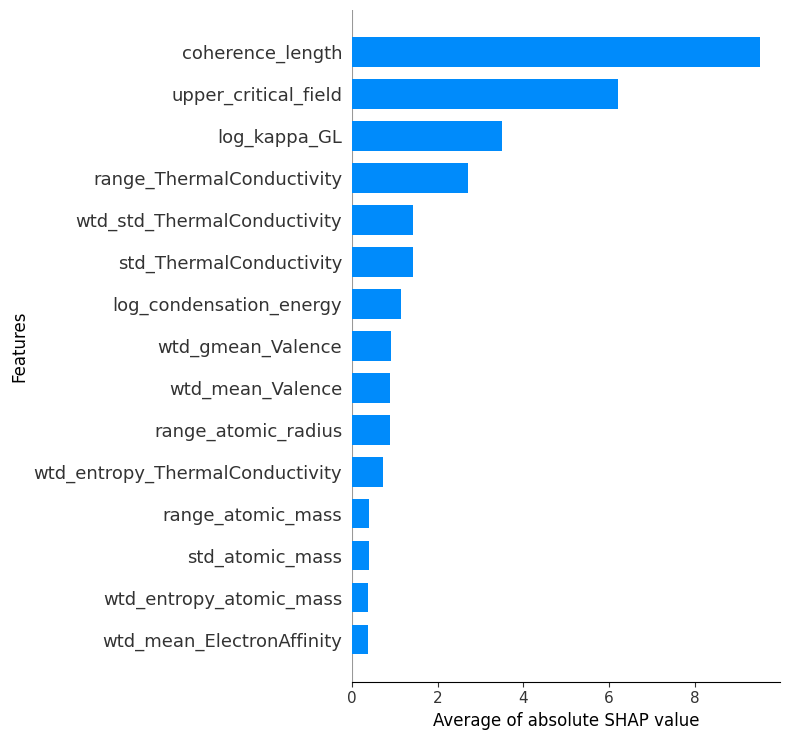

In [ ]:
# ── Plot 1: Bar chart ──────────────────────────────────
shap.summary_plot(
    shap_value, samples_for_shap,
    plot_type    = "bar",
    max_display  = 15,
    show         = False
)
plt.xlabel('Average of absolute SHAP value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=600, bbox_inches='tight')
plt.show()


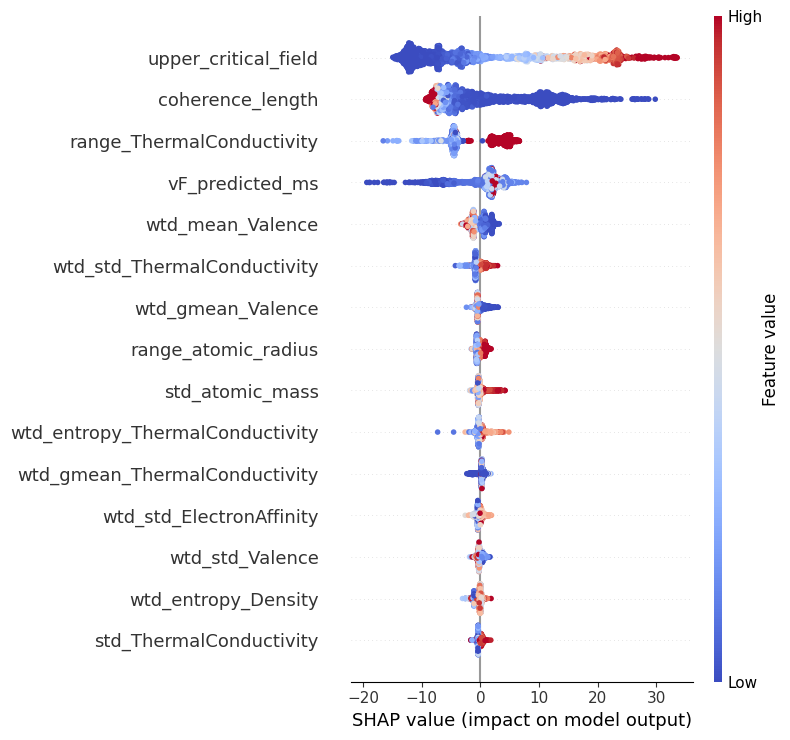

In [5]:

# ── Plot 2: Beeswarm ───────────────────────────────────
shap.summary_plot(
    shap_value, samples_for_shap,
    max_display = 15,
    show        = False,
    cmap='coolwarm' # Red/Blue color scheme
)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:

# ── Plot 3: Dependence plots ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
shap.dependence_plot(
    "upper_critical_field", shap_value, samples_for_shap,
    interaction_index = "coherence_length",
    ax=axes[0], show=False
)
shap.dependence_plot(
    "coherence_length", shap_value, samples_for_shap,
    interaction_index = "upper_critical_field",
    ax=axes[1], show=False
)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Plot 4: Direct scatter (Tc vs top 2 features) ─────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_test['upper_critical_field'],
                y_test, alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('upper_critical_field', fontsize=12)
axes[0].set_ylabel('Critical Temperature Tc (K)', fontsize=12)
axes[0].set_title('upper_critical_field vs Tc', fontsize=13)

axes[1].scatter(X_test['coherence_length'],
                y_test, alpha=0.3, s=10, color='darkorange')
axes[1].set_xlabel('coherence_length', fontsize=12)
axes[1].set_ylabel('Critical Temperature Tc (K)', fontsize=12)
axes[1].set_title('coherence_length vs Tc', fontsize=13)

plt.tight_layout()
plt.savefig('feature_vs_tc.png', dpi=300, bbox_inches='tight')
plt.show()